In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dill
import warnings
warnings.filterwarnings("ignore")

In [2]:
import json
with open("./vtem_max.json", "r") as file:
    vtem_et_dict = json.load(file)

In [3]:
vtem_et_dict.keys()

dict_keys(['times', 'currents', 'current_times'])

In [4]:
times_orig = np.array(vtem_et_dict['times'])
currents = np.array(vtem_et_dict['currents'])
current_times = np.array(vtem_et_dict['current_times'])

In [5]:
survey_name = f'GL250259_VTEMMax_Preliminary_F12'

In [6]:
df_data = pd.read_csv(f"../../Tuloasa/vtem-max/{survey_name}.csv")
df_data = df_data[~np.isnan(df_data['x'])]

In [7]:
i_start = 4
i_end = 43
data_header = np.array([f'SFz[{ii}]' for ii in range(4, 50)])[i_start:i_end]
data_header = data_header.tolist()
times = times_orig[i_start:i_end]

In [8]:
data_header

['SFz[8]',
 'SFz[9]',
 'SFz[10]',
 'SFz[11]',
 'SFz[12]',
 'SFz[13]',
 'SFz[14]',
 'SFz[15]',
 'SFz[16]',
 'SFz[17]',
 'SFz[18]',
 'SFz[19]',
 'SFz[20]',
 'SFz[21]',
 'SFz[22]',
 'SFz[23]',
 'SFz[24]',
 'SFz[25]',
 'SFz[26]',
 'SFz[27]',
 'SFz[28]',
 'SFz[29]',
 'SFz[30]',
 'SFz[31]',
 'SFz[32]',
 'SFz[33]',
 'SFz[34]',
 'SFz[35]',
 'SFz[36]',
 'SFz[37]',
 'SFz[38]',
 'SFz[39]',
 'SFz[40]',
 'SFz[41]',
 'SFz[42]',
 'SFz[43]',
 'SFz[44]',
 'SFz[45]',
 'SFz[46]']

In [9]:
data = df_data[data_header].values

In [10]:
data

array([[ 2.08261471e+01,  1.98188248e+01,  1.85788078e+01, ...,
         3.82787408e-03,  3.00399284e-03,  2.18438543e-03],
       [ 2.09461441e+01,  1.99377155e+01,  1.86969585e+01, ...,
         3.82923987e-03,  3.00413230e-03,  2.18106550e-03],
       [ 2.10660172e+01,  2.00560951e+01,  1.88142128e+01, ...,
         3.83479963e-03,  3.00233066e-03,  2.17788271e-03],
       ...,
       [ 6.34849668e-01,  5.05879939e-01,  3.84964317e-01, ...,
         5.67105773e-04,  3.64553387e-04, -3.39354476e-04],
       [ 6.31587207e-01,  5.04123747e-01,  3.83450031e-01, ...,
         4.74434521e-04,  4.09863016e-04, -3.53289710e-04],
       [ 6.28229320e-01,  5.02338886e-01,  3.81874710e-01, ...,
         3.96895455e-04,  4.48645529e-04, -3.63071420e-04]])

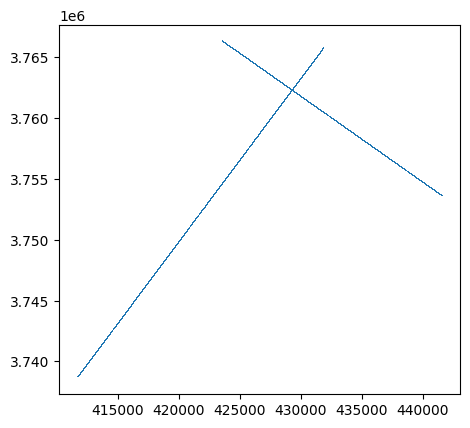

In [11]:
xy = df_data[['x', 'y']].values
plt.plot(xy[:,0], xy[:,1], ',')
plt.gca().set_aspect(1)

In [12]:
uniq_lines = np.unique(df_data['Line'].values)

In [13]:
df_data.shape[0] / 200

91.525

# Stacking raw AEM data over about 30-40 m interval (i.e. binning)

In [14]:
import pandas as pd
dx = 40.
values = []
values_std = []
for i_line, line in enumerate(uniq_lines):
    df_line = df_data[df_data['Line']==line]
    
    df_line = df_line.copy()

    xy = df_line[['x', 'y']].values
    distance = np.sqrt(((xy - xy[0,:])**2).sum(axis=1))
    n_sounding = np.round(distance.max() / dx) + 1
    bins = np.arange(n_sounding) * dx
    df_line.insert(0, 'distance', distance)
    # Bin distances
    df_line['bin'] = pd.cut(df_line['distance'], bins=bins)

    # Compute statistics per bin
    binned = (
        df_line.groupby('bin', observed=False)
               [['distance','x','y','DEM','radar','radarb','PLM'] + data_header]
               .mean()
    )
    binned.insert(0, 'line', line)
    binned_std = (
        df_line.groupby('bin', observed=False)
               [['DEM','radar','radarb'] + data_header]
               .std()
    )
    values.append(binned.values)
    values_std.append(binned_std.values)
df_data_binned = pd.DataFrame(data=np.vstack(values), columns=['Line', 'distance','x','y','DEM','radar','radarb','PLM'] + data_header)
df_data_std_binned = pd.DataFrame(data=np.vstack(values_std), columns=['DEM','radar','radarb'] + data_header)

# TODOs
- Expand the binning in a way that can handle a larger swath for the later time gates, so do it by channel [done]
- Make sure the bin interval is about 40 m while the swath could be much bigger hundres of meters 
- There are relatively large errors on early time gates due to flight height change ... how to handle?
    - problem 1: accuracy issue of the code
    - problem 2: hard to fit the data
- May be remove data greater than XX me height

In [15]:
from sklearn.preprocessing import MinMaxScaler
# Create scaler
from ipywidgets import widgets, interact

In [16]:
def foo(line):
    fig, axs = plt.subplots(2,1, figsize=(20, 10))
    ax0, ax = axs

    # line = uniq_lines[i_line]
    df_data_binned_line = df_data_binned[df_data_binned['Line']==line]
    ax0.plot(df_data_binned['x'], df_data_binned['y'], '.')    
    ax0.plot(df_data_binned_line['x'], df_data_binned_line['y'], '.')
    ax0.plot(df_data_binned_line['x'].values[0], df_data_binned_line['y'].values[0], 'o')
    ax0.set_aspect(1)
    scaler = MinMaxScaler(feature_range=(df_data_binned_line['radarb'].min(), df_data_binned_line['radarb'].max()))
    plm_norm = scaler.fit_transform(df_data_binned_line['PLM'].values.reshape([-1,1]))

    ax_1 = ax.twinx()
    ax.semilogy(df_data_binned_line['distance'], df_data_binned_line[data_header], color='k', lw=1)
    ax_1.plot(df_data_binned_line['distance'], plm_norm, '-', color='red', label='PLM')
    ax_1.plot(df_data_binned_line['distance'], df_data_binned_line['radarb'], '-', label='Flight height')
    ax_1.legend()
interact(foo, line=widgets.Select(options=uniq_lines))

interactive(children=(Select(description='line', options=('L2040', 'L2090'), value='L2040'), Output()), _dom_c…

<function __main__.foo(line)>

In [17]:
data = df_data_binned[data_header].values.astype(float)
data_rerr = (df_data_std_binned[data_header].values / abs(df_data_binned[data_header].values)).astype(float)
channel_index = np.tile(np.arange(data.shape[1]), (data.shape[0], 1))
line_index = np.tile(df_data_binned['Line'].values, (data.shape[1], 1)).T
height_index = np.tile(df_data_binned['radarb'].values, (data.shape[1], 1)).T
plm_index = np.tile(df_data_binned['PLM'].values, (data.shape[1], 1)).T
noise_level = 0.0005 #pV/A/m4
ind_omit = np.logical_and(data_rerr>0.05, channel_index>=0) | (data<noise_level)
ind_large_error = np.logical_or(plm_index>0.5, height_index>60)
# ind_omit = np.logical_and(data_rerr>0.05, channel_index>=0)
# ind_omit_line = np.logical_and(data_rerr>0.01, channel_index>=0) & (line_index =='L100')
data_rerr[ind_large_error] = abs(data[ind_large_error]) * 0.3
data[ind_omit] = np.nan
data_rerr[ind_omit] = np.nan

In [18]:
other_values = df_data_binned[['Line', 'distance','x','y','DEM','radar','radarb','PLM']].values
df_data_binned_filtered = pd.DataFrame(data=np.hstack((other_values, data)), columns=['Line', 'distance','x','y','DEM','radar','radarb','PLM'] + data_header)

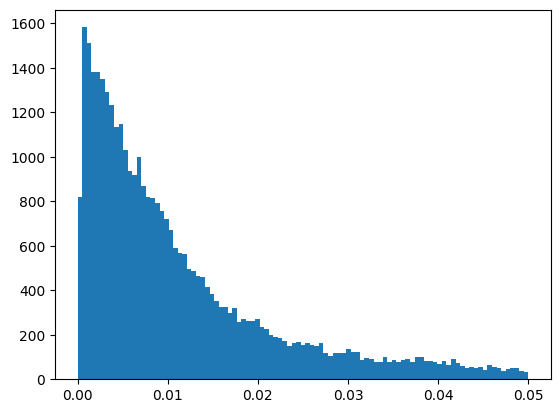

In [19]:
out = plt.hist(data_rerr[~ind_omit], bins=np.linspace(0., 0.05, 100))

In [20]:
df_data_binned_line_filtered = df_data_binned_filtered[df_data_binned_filtered['Line']==line]

In [21]:
def foo(line):
    fig, axs = plt.subplots(3,1, figsize=(20, 15))
    ax0, ax, ax1 = axs

    # line = uniq_lines[i_line]
    df_data_binned_line_filtered = df_data_binned_filtered[df_data_binned_filtered['Line']==line]
    df_data_binned_line = df_data_binned[df_data_binned['Line']==line]
    ax0.plot(df_data_binned_filtered['x'], df_data_binned_filtered['y'], '.')    
    ax0.plot(df_data_binned_line['x'], df_data_binned_line['y'], '.')
    ax0.plot(df_data_binned_line['x'].values[0], df_data_binned_line['y'].values[0], 'o')
    ax0.set_aspect(1)
    scaler = MinMaxScaler(feature_range=(df_data_binned_line['radarb'].min(), df_data_binned_line['radarb'].max()))
    plm_norm = scaler.fit_transform(df_data_binned_line['PLM'].values.reshape([-1,1]))

    ax_1 = ax.twinx()
    ax.semilogy(df_data_binned_line['distance'], df_data_binned_line[data_header], color='k', lw=1)
    ax_1.plot(df_data_binned_line['distance'], plm_norm, '-', color='red', label='PLM')
    ax_1.plot(df_data_binned_line['distance'], df_data_binned_line['radarb'], '-', label='Flight height')
    ax_1.legend()
    
    ax1_1 = ax1.twinx()
    ax1.semilogy(df_data_binned_line['distance'], df_data_binned_line_filtered[data_header], color='k', lw=1)
    ax1_1.plot(df_data_binned_line['distance'], plm_norm, '-', color='red', label='PLM')
    ax1_1.plot(df_data_binned_line['distance'], df_data_binned_line['radarb'], '-', label='Flight height')
    ax1_1.legend()
    
interact(foo, line=widgets.Select(options=uniq_lines))

interactive(children=(Select(description='line', options=('L2040', 'L2090'), value='L2040'), Output()), _dom_c…

<function __main__.foo(line)>

In [22]:
from ipywidgets import interact, widgets

In [23]:
data.shape

(1396, 39)

In [24]:
data_rerr.shape

(1396, 39)

In [25]:
times.shape

(39,)

In [26]:
# # i_sounding = 0
# def foo(i_sounding):
#     plt.errorbar(times, data[i_sounding,:], yerr=data_rerr[i_sounding,:]*5)
#     plt.yscale('log')
#     plt.xscale('log')
#     # plt.title(f"{binned['distance'].values[i_sounding]:.1f}")
# interact(foo, i_sounding = widgets.IntSlider(min=0, max=data.shape[0]-1, continous_update=False, step=5))    

In [27]:
ind_omit.shape

(1396, 39)

In [28]:
dobs = -df_data_binned[data_header].values.flatten() * 1e-12
tmp_std = df_data_std_binned[data_header].values.flatten() * 1e-12
dobs_std = abs(dobs) * 0.03
dobs_std[tmp_std > abs(dobs) * 0.03]=tmp_std[tmp_std > abs(dobs) * 0.03]
# dobs_std[ind_large_error.flatten()] = abs(dobs)[ind_large_error.flatten()] * 0.3
dobs_std[ind_omit.flatten()] = np.inf


In [29]:
from simpeg.electromagnetics.utils.em1d_utils import get_vertical_discretization
topography = df_data_binned[['x','y', 'DEM']].values
source_heights = df_data_binned['radarb'].values
thickness = get_vertical_discretization(39, 3, 1.07)

>> Depth from the surface to the base of the bottom layer is 556.9m


In [30]:
i_sounding = 0
# source_heights[i_sounding]

In [31]:
from simpeg import maps
import simpeg.electromagnetics.time_domain as tdem
from pymatsolver import PardisoSolver
import simpeg
from types import SimpleNamespace

In [32]:
input_data_dict = {
    "topography": topography.astype(float),
    "source_heights": source_heights.astype(float),
    "thickness": thickness,
    "time_input_currents":current_times,
    "input_currents":currents,
    "times":times,    
    "data":dobs,
    "data_std":dobs_std,    
}
inp = SimpleNamespace(**input_data_dict)

In [33]:
radius = np.sqrt(1/np.pi)

In [34]:
# np.pi * radius **2

In [35]:
# !mkdir inversion_results_GL250194_F1
get_ipython().system(f'mkdir inversion_results_{survey_name}')

mkdir: inversion_results_GL250259_VTEMMax_Preliminary_F12: File exists


In [36]:
source_locations = np.c_[inp.topography[:,0], inp.topography[:,1], inp.topography[:,2]+inp.source_heights]
receiver_locations = np.c_[inp.topography[:,0], inp.topography[:,1],  inp.topography[:,2]+inp.source_heights]
n_sounding = source_locations.shape[0]

source_list = []
receiver_orientation = 'z'
source_orientation = 'z'
for i_sounding in range(n_sounding):    
    waveform = tdem.sources.PiecewiseLinearWaveform(inp.time_input_currents, inp.input_currents)
    source_location = source_locations[i_sounding, :]
    receiver_location = receiver_locations[i_sounding, :]

    # Receiver list

    dbzdt_receiver = tdem.receivers.PointMagneticFluxTimeDerivative(
            receiver_location, inp.times, "z",
    )

    # Make a list containing all receivers even if just one

    # Must define the transmitter properties and associated receivers

    source_list.append(tdem.sources.CircularLoop(
        [dbzdt_receiver],
        location=source_location,
        waveform=waveform,
        radius=radius,
        i_sounding=i_sounding,
    )
    )

survey = tdem.Survey(source_list)
hz = np.r_[inp.thickness, inp.thickness[-1]]

n_layer = len(hz)
nP = n_sounding * n_layer
sigma_map = maps.ExpMap(nP=nP)

simulation = tdem.Simulation1DLayeredStitched(
    survey=survey, 
    thicknesses=inp.thickness, 
    sigmaMap=sigma_map,
    topo=inp.topography, 
    parallel=True, 
    n_cpu=8, 
    verbose=False, 
    solver=PardisoSolver,
)

n_time = inp.times.size

noise_floor = 0.

# Create data ojbect
data_object = simpeg.data.Data(survey, dobs=dobs, standard_deviation=inp.data_std)
dmis = simpeg.data_misfit.L2DataMisfit(simulation=simulation, data=data_object)
inds_active_dobs = dobs==9999
print (f"Percentage of the active data = {inds_active_dobs.sum()}/{len(dobs)}={inds_active_dobs.sum()/len(dobs)*100:.0f}%")

from simpeg.electromagnetics.utils.em1d_utils import set_mesh_1d
import scipy
from discretize import SimplexMesh
from simpeg.regularization.laterally_constrained import LaterallyConstrained

tri = scipy.spatial.Delaunay(inp.topography[:,:2])
mesh_radial = SimplexMesh(tri.points, tri.simplices)
mesh_vertical = set_mesh_1d(hz)
mesh_reg = [mesh_radial, mesh_vertical]

def get_active_edge_indices_with_distance(mesh_radial, mesh_vertical, maximum_distance=1000):
    nz = mesh_vertical.n_cells
    edge_lengths = mesh_radial.edge_lengths
    inds = edge_lengths < maximum_distance
    indActiveEdges = np.tile(inds.reshape([-1,1]), nz).flatten()
    return inds, indActiveEdges

inds, indActiveEdges = get_active_edge_indices_with_distance(
    mesh_radial, mesh_vertical, maximum_distance=500.
)

reg = LaterallyConstrained(
    mesh_reg, 
    mapping=simpeg.maps.IdentityMap(nP=nP),
    alpha_s = 0.,
    alpha_r = 1.,
    alpha_z = 1./2.,
    active_edges=indActiveEdges
)

opt = simpeg.optimization.ProjectedGNCG(maxIter=20, maxIterCG=50)
invProb = simpeg.inverse_problem.BaseInvProblem(dmis, reg, opt)
beta = simpeg.directives.BetaSchedule(coolingFactor=2, coolingRate=1)
betaest = simpeg.directives.BetaEstimate_ByEig(beta0_ratio=1.)
target = simpeg.directives.TargetMisfit(chifact=1)
precond = simpeg.directives.UpdatePreconditioner()
save_model_dict = simpeg.directives.SaveOutputDictEveryIteration()
save_model_dict.outDict = {}

inv = simpeg.inversion.BaseInversion(
    invProb, 
    directiveList=[
        betaest, 
        beta, 
        precond,
        target, 
        save_model_dict
    ]
)
invProb.counter = opt.counter = simpeg.utils.Counter()
opt.LSshorten = 0.5
opt.remember('xc')
m0 = np.ones(nP) * np.log(1./10.)
mest = inv.run(m0)

import dill
dill.dump(save_model_dict.outDict, open(f"./inversion_results_{survey_name}.pik", "wb"))


Percentage of the active data = 0/54444=0%

Running inversion with SimPEG v0.25.0
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.

                        simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                        ***Done using same Solver, and solver_opts as the Simulation1DLayeredStitched problem***
                        
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
model has any nan: 0
=============================== Projected GNCG ===============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
--------------------------------------------------------------

In [52]:
outDict = dill.load(open(f"./inversion_results_{survey_name}.pik", "rb"))

In [54]:
iteration = len(outDict.keys())
m = outDict[iteration]['m']
dpred = outDict[iteration]['dpred']
DPRED = dpred.reshape((n_sounding, n_time))
DOBS = dobs.reshape((n_sounding, n_time))
DOBS[ind_omit] = np.nan
DPRED[ind_omit] = np.nan
STD = data_object.standard_deviation.reshape((n_sounding, n_time))

In [55]:
rho = 1. / np.exp(m)

[Text(0.0, 0, '1'),
 Text(0.5, 0, '3'),
 Text(1.0, 0, '10'),
 Text(1.5, 0, '32'),
 Text(2.0, 0, '100'),
 Text(2.5, 0, '316'),
 Text(3.0, 0, '1000'),
 Text(3.5, 0, '3162'),
 Text(4.0, 0, '10000')]

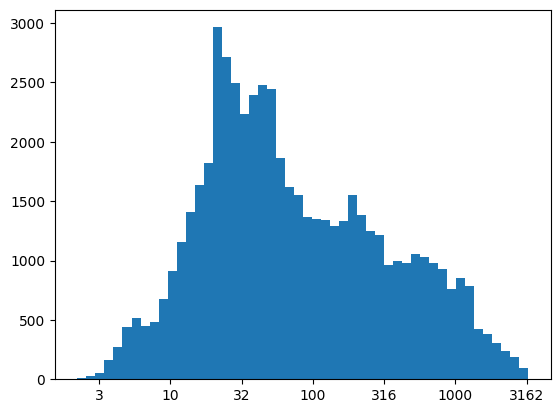

In [56]:
out = plt.hist(np.log10(rho), bins=50)
xticks = plt.xticks()[0]
plt.gca().set_xticklabels([f"{10**x:.0f}" for x in xticks])

In [57]:
other_values = df_data_binned[['Line', 'distance','x','y','DEM','radar','radarb','PLM']].values
df_data_binned_pred = pd.DataFrame(data=np.hstack((other_values, -DPRED * 1e12)), columns=['Line', 'distance','x','y','DEM','radar','radarb','PLM'] + data_header)


In [58]:
# i_sounding = 0
def foo(i_sounding):
    plt.plot(times, -DOBS[i_sounding,:], '.')
    plt.plot(times, -DPRED[i_sounding,:])
    plt.yscale('log')
    plt.xscale('log')
    # plt.title(f"{binned['x'].values[i_sounding]:.1f}")
interact(foo, i_sounding = widgets.IntSlider(min=0, max=n_sounding-1, continous_update=False))    


interactive(children=(IntSlider(value=0, description='i_sounding', max=1395), Output()), _dom_classes=('widget…

<function __main__.foo(i_sounding)>

In [61]:
from simpeg.electromagnetics.utils.em1d_utils import Stitched1DModel

In [62]:
line = np.array([int(val.strip('L').strip('T')) for val in df_data_binned['Line'].values])

In [63]:
# line_modified = line.copy()
# line_modified[line_modified==1020] = 1010
# uniq_lines_modified = uniq_lines[uniq_lines!='L1020']

In [64]:
model = Stitched1DModel(
    topography=inp.topography,
    physical_property=1./np.exp(m),
    line=line,
    time_stamp=np.arange(n_sounding),
    thicknesses=thickness,    
)

In [65]:
# model.get_3d_mesh(dx=200, dy=200)
# model.get_interpolation_matrix()
# rho_3d = model.interpolate_from_1d_to_3d(1./np.exp(m))
# from verde import distance_mask
# mask = distance_mask(
#     (inp.topography[:,0], inp.topography[:,1]), 
#     maxdist=500, 
#     coordinates=(model.mesh_3d.cell_centers[:,0], model.mesh_3d.cell_centers[:,1])
# )
# resistivity_3d = rho_3d.flatten(order='F')
# resistivity_3d[~mask] = np.nan
# model.mesh_3d.write_vtk(f'inversion_results_{survey_name}/rho_3d.vtr', models={'rho':resistivity_3d})

In [66]:
# df_data_binned_line[data_header]

In [67]:
def foo(line):
    fig, axs = plt.subplots(2,1, figsize=(20, 10))
    ax0, ax = axs

    # line = uniq_lines[i_line]
    df_data_binned_line = df_data_binned[df_data_binned['Line']==line]
    df_data_binned_pred_line = df_data_binned_pred[df_data_binned_pred['Line']==line]

    ax0.plot(df_data_binned['x'], df_data_binned['y'], '.')    
    ax0.plot(df_data_binned_line['x'], df_data_binned_line['y'], '.')
    ax0.plot(df_data_binned_line['x'].values[0], df_data_binned_line['y'].values[0], 'o')
    ax0.set_aspect(1)
    scaler = MinMaxScaler(feature_range=(df_data_binned_line['radarb'].min(), df_data_binned_line['radarb'].max()))
    plm_norm = scaler.fit_transform(df_data_binned_line['PLM'].values.reshape([-1,1]))

    ax_1 = ax.twinx()
    ax.semilogy(df_data_binned_line['distance'], df_data_binned_line[data_header], 'k-', lw=0.5)
    ax.semilogy(df_data_binned_pred_line['distance'], df_data_binned_pred_line[data_header], 'b--', lw=0.5)
    ax_1.plot(df_data_binned_line['distance'], plm_norm, '-', color='red', label='PLM')
    ax_1.plot(df_data_binned_line['distance'], df_data_binned_line['radarb'], '-', label='Flight height')
    ax_1.legend()
    ax.set_xlim(df_data_binned_line['distance'].min(), df_data_binned_line['distance'].max())
Q = interact(foo, line=widgets.Select(options=uniq_lines))

interactive(children=(Select(description='line', options=('L2040', 'L2090'), value='L2040'), Output()), _dom_c…

Text(0.5, 1.0, 'L2040')

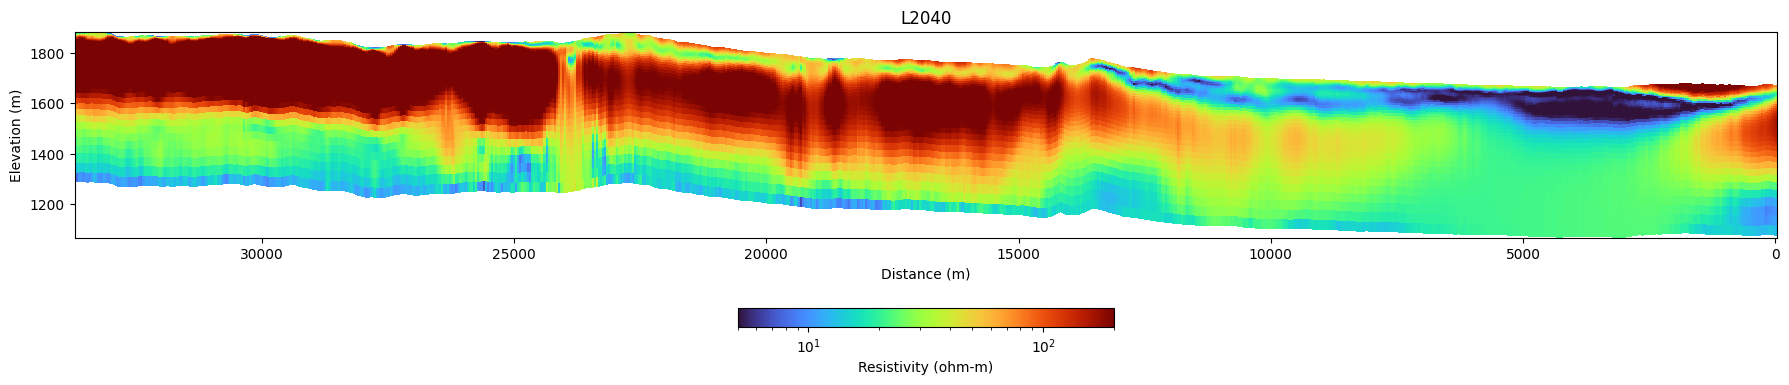

In [68]:
fig, ax2 = plt.subplots(1,1, figsize=(18, 5))
out, ax2 = model.plot_section(x_axis='distance', aspect=5, dx=30., alpha=1, cmap='turbo', 
                              clim=(5, 200), invert_xaxis=True,
                              ax=ax2, show_colorbar=False, i_line=np.argwhere(uniq_lines==Q.widget.kwargs['line'] )[0][0])
cb = plt.colorbar(out, ax=ax2, orientation='horizontal', fraction=0.04)
cb.set_label("Resistivity (ohm-m)")
ax2.set_title(Q.widget.kwargs['line'])

In [69]:
# mkdir inversion_results_GL250193_F02

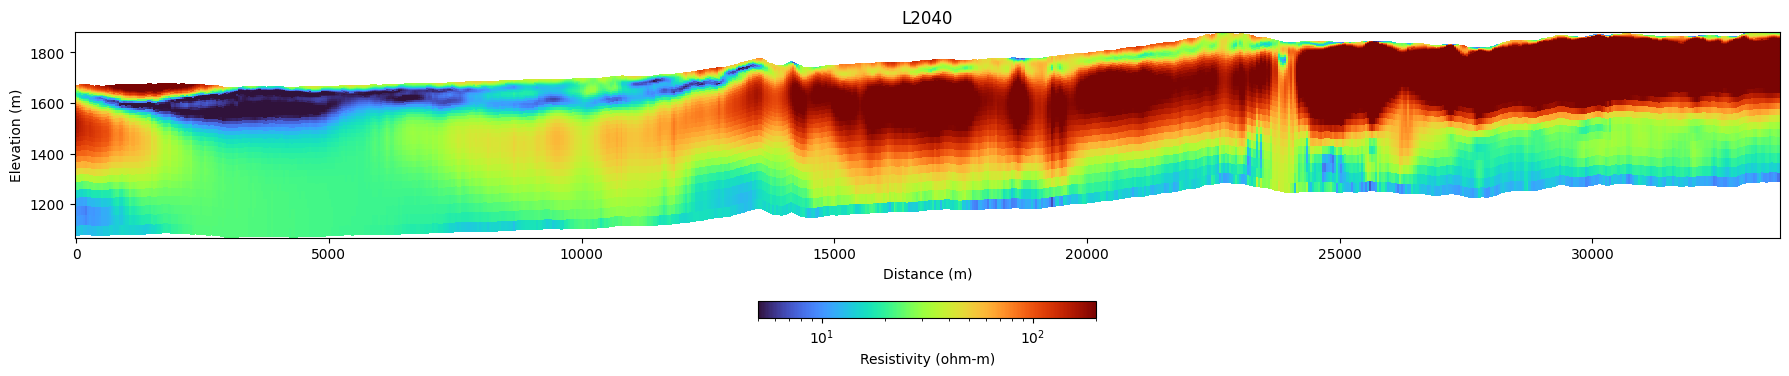

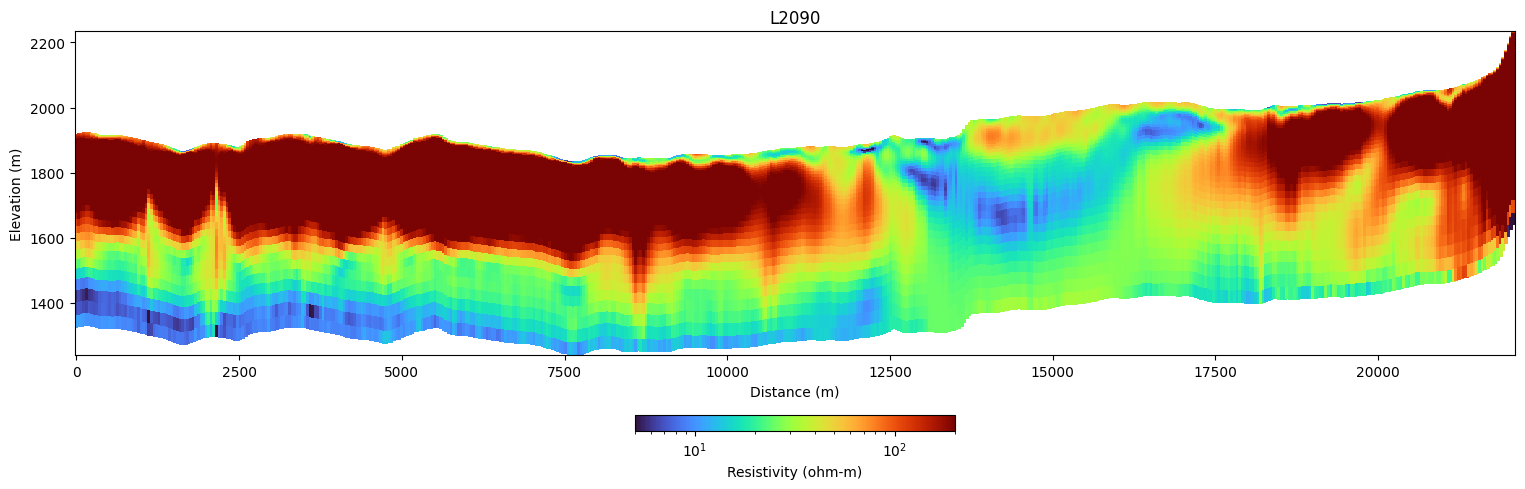

In [70]:
for i_line in range(len(uniq_lines)):
    fig, ax2 = plt.subplots(1,1, figsize=(18, 5))
    out, ax2 = model.plot_section(x_axis='distance', aspect=5, dx=30., alpha=1, cmap='turbo', clim=(5, 200), ax=ax2, show_colorbar=False, i_line=i_line)
    cb = plt.colorbar(out, ax=ax2, orientation='horizontal', fraction=0.04)
    cb.set_label("Resistivity (ohm-m)")
    line = uniq_lines[i_line]
    ax2.set_title(line)
    plt.tight_layout()
    fig.savefig(f"./inversion_results_{survey_name}/{line}.png", dpi=200)
    

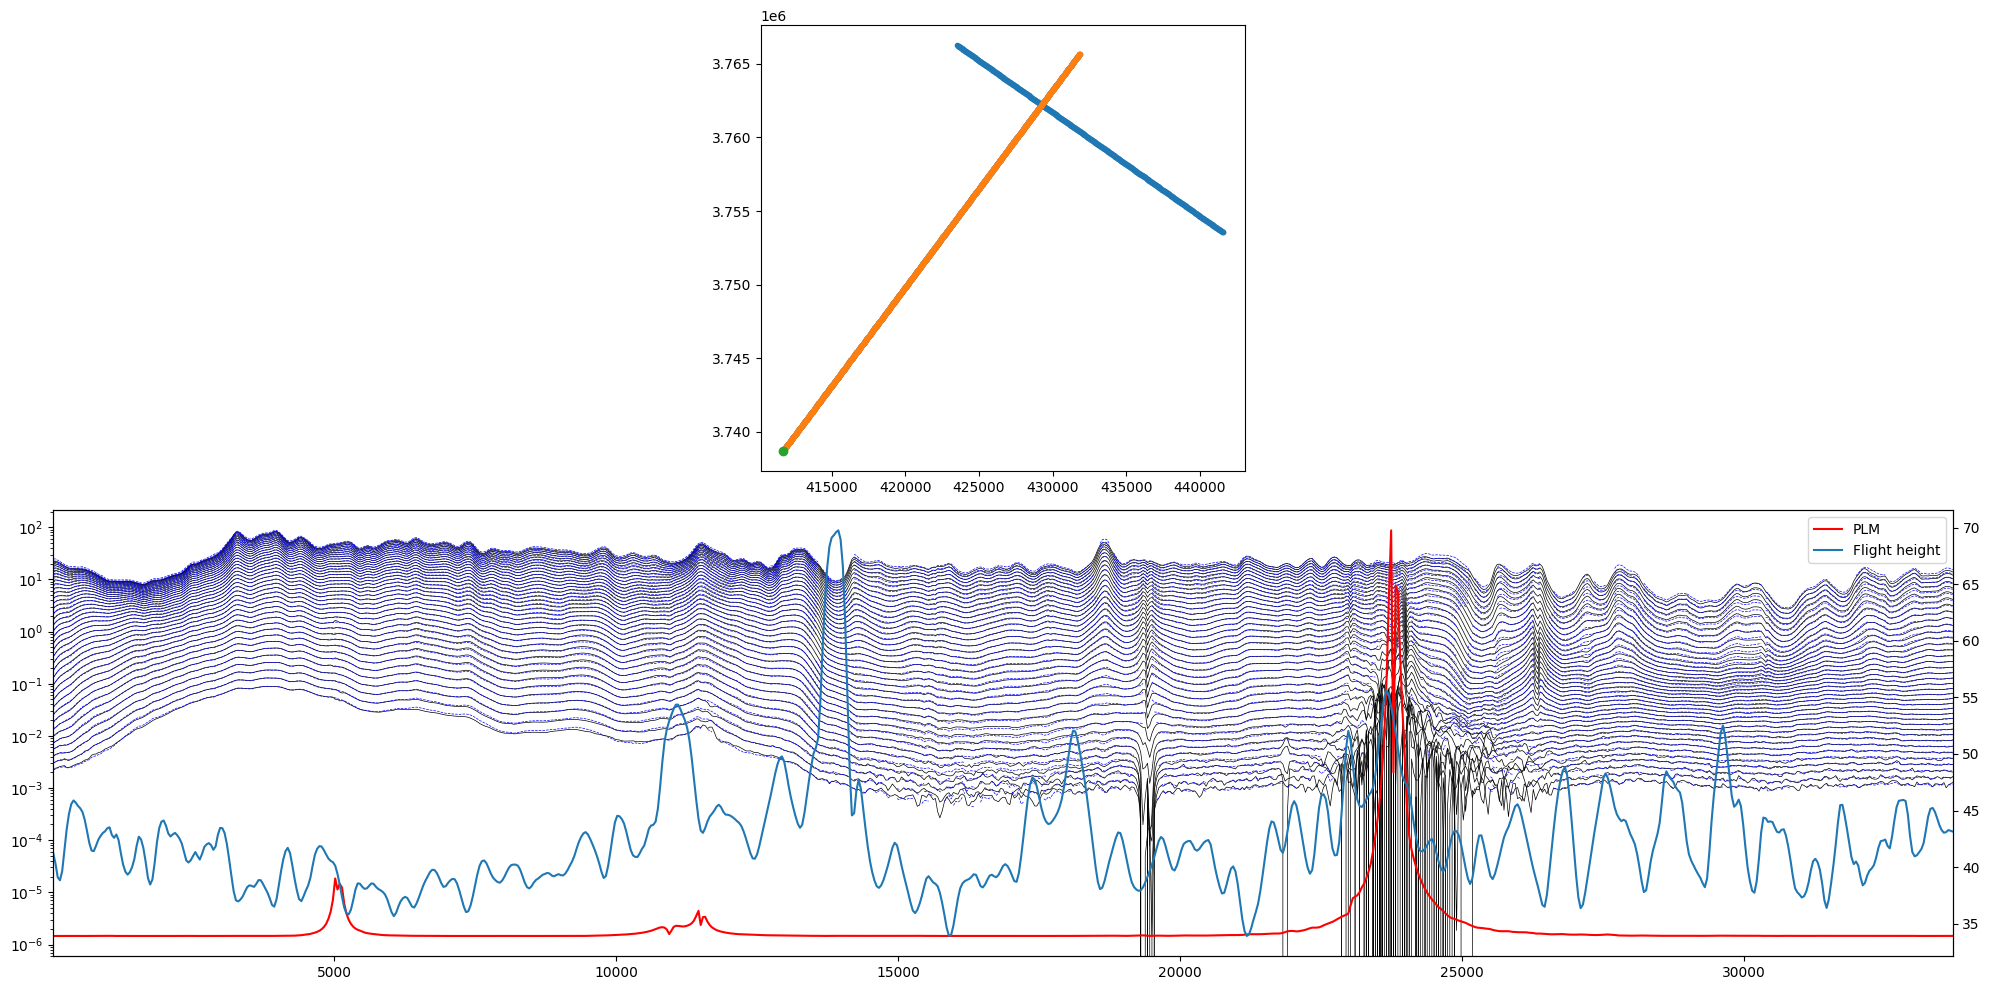

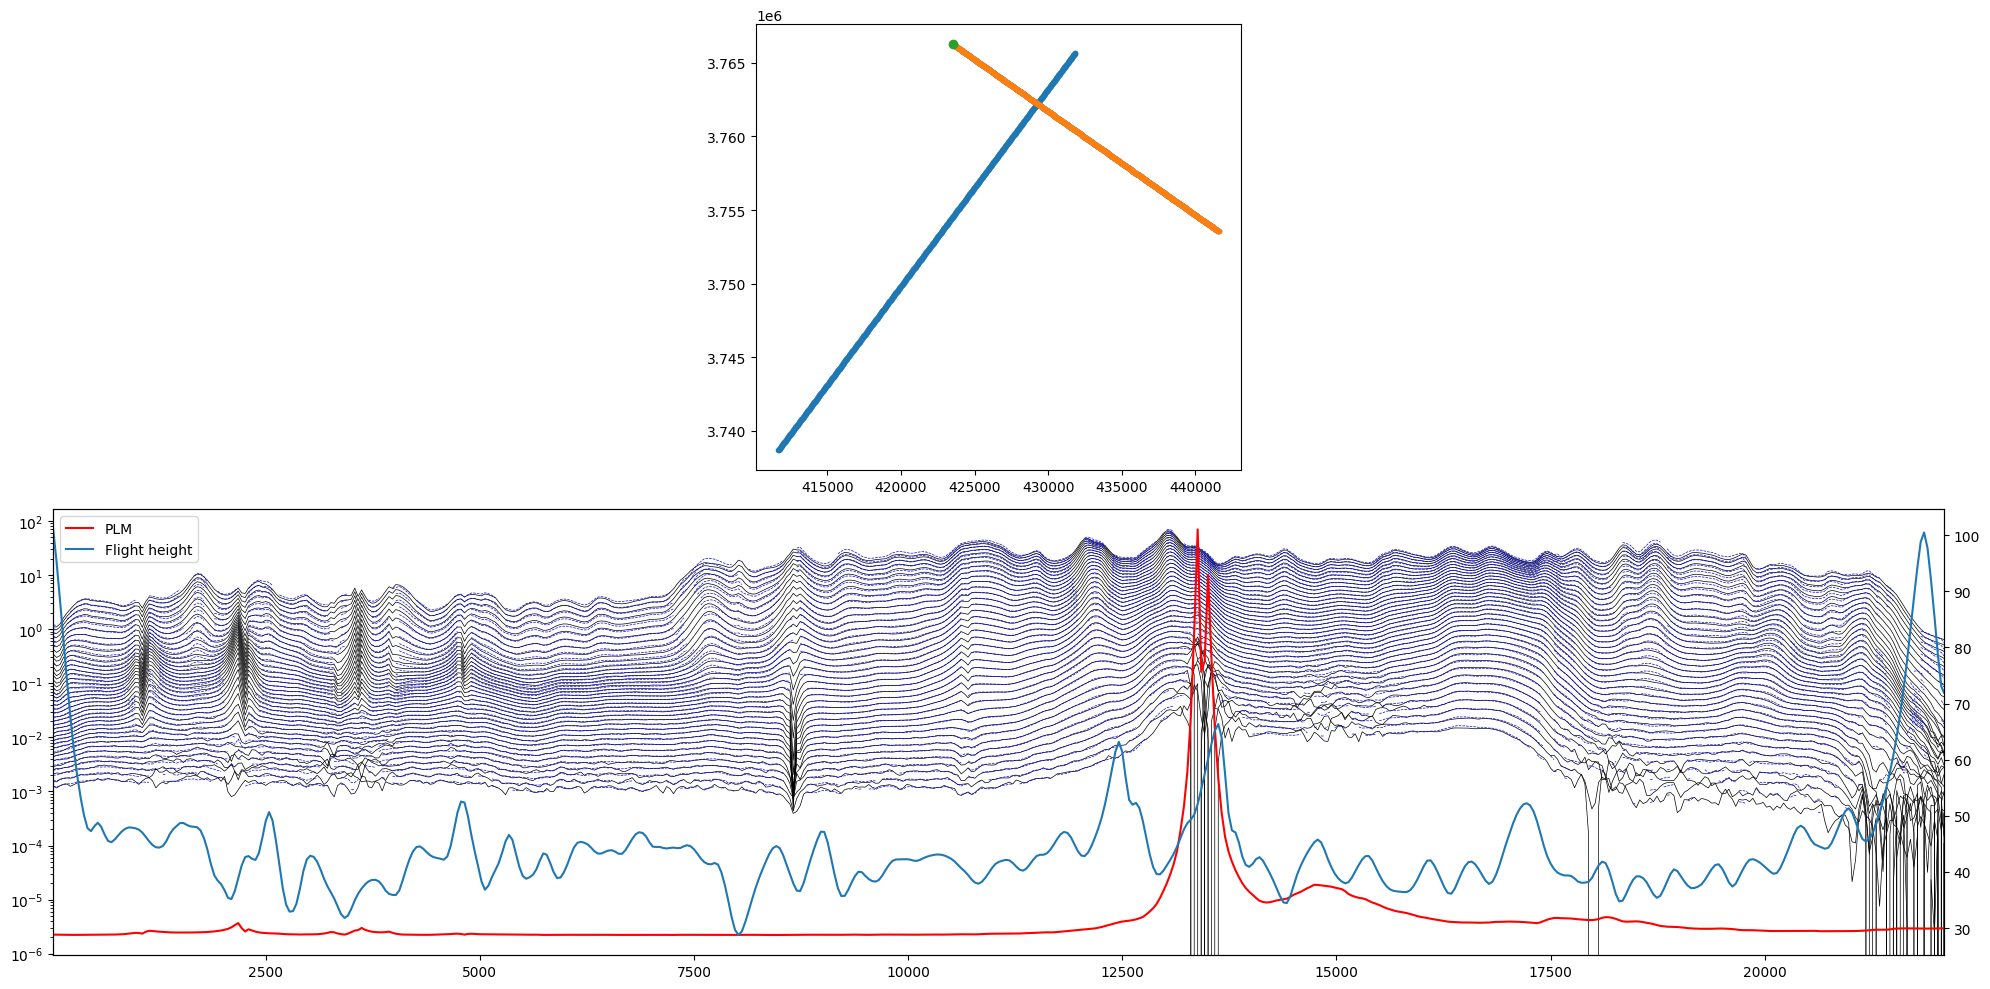

In [71]:
for line in uniq_lines:
    fig, axs = plt.subplots(2,1, figsize=(20, 10))
    ax0, ax = axs

    # line = uniq_lines[i_line]
    df_data_binned_line = df_data_binned[df_data_binned['Line']==line]
    df_data_binned_pred_line = df_data_binned_pred[df_data_binned_pred['Line']==line]

    ax0.plot(df_data_binned['x'], df_data_binned['y'], '.')    
    ax0.plot(df_data_binned_line['x'], df_data_binned_line['y'], '.')
    ax0.plot(df_data_binned_line['x'].values[0], df_data_binned_line['y'].values[0], 'o')
    ax0.set_aspect(1)
    scaler = MinMaxScaler(feature_range=(df_data_binned_line['radarb'].min(), df_data_binned_line['radarb'].max()))
    plm_norm = scaler.fit_transform(df_data_binned_line['PLM'].values.reshape([-1,1]))

    ax_1 = ax.twinx()
    ax.semilogy(df_data_binned_line['distance'], df_data_binned_line[data_header], 'k-', lw=0.5)
    ax.semilogy(df_data_binned_pred_line['distance'], df_data_binned_pred_line[data_header], 'b--', lw=0.5)
    ax_1.plot(df_data_binned_line['distance'], plm_norm, '-', color='red', label='PLM')
    ax_1.plot(df_data_binned_line['distance'], df_data_binned_line['radarb'], '-', label='Flight height')
    ax_1.legend()
    ax.set_xlim(df_data_binned_line['distance'].min(), df_data_binned_line['distance'].max())
    plt.tight_layout()
    fig.savefig(f"./inversion_results_{survey_name}/{line}_data.png", dpi=200)
    

In [72]:
# fig, ax1 = plt.subplots(1,1, figsize=(18, 5))

# ax_1 = ax1.twinx()
# i_line = 5
# line = uniq_lines[i_line]
# df_data_binned_line = df_data_binned[df_data_binned['Line']==line]
# df_data_binned_pred_line = df_data_binned_pred[df_data_binned_pred['Line']==line]
# ax1.semilogy(df_data_binned_line['distance'], df_data_binned_line[data_header], 'k-', lw=1)
# out = ax1.semilogy(df_data_binned_line['distance'], df_data_binned_pred_line[data_header], 'b--', lw=1)
# scaler = MinMaxScaler(feature_range=(df_data_binned_line['radarb'].min(), df_data_binned_line['radarb'].max()))
# plm_norm = scaler.fit_transform(df_data_binned_line['PLM'].values.reshape([-1,1]))
# # ax_1.plot(binned['distance'], binned['radarb'], 'r-')
# ax_1.plot(df_data_binned_line['distance'], plm_norm, '-', color='red', label='PLM')
# ax_1.plot(df_data_binned_line['distance'], df_data_binned_line['radarb'], '-', label='Flight height')

# # ax1.set_xlim(binned['x'].min(), binned['x'].max())


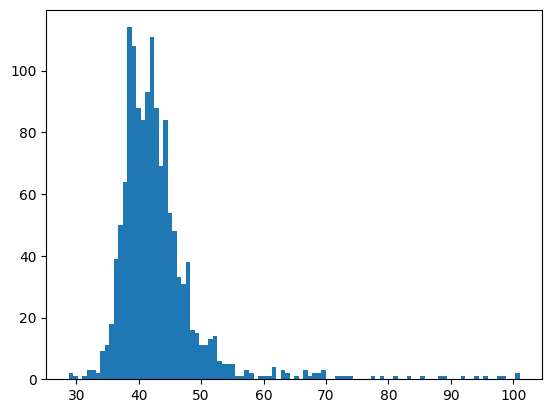

In [73]:
out = plt.hist(df_data_binned['radarb'].values, bins=100)

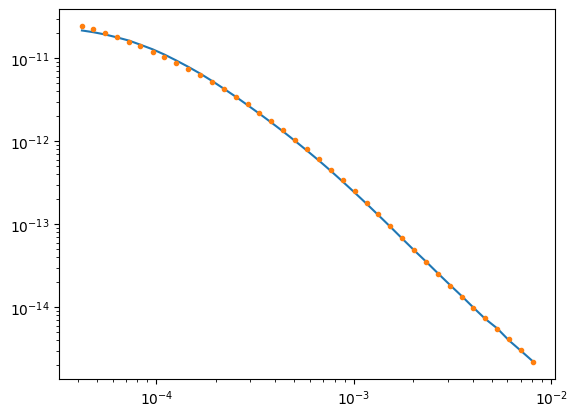

In [74]:
plt.loglog(times, -DOBS[0,:])
plt.loglog(times, -DPRED[0,:], '.')

In [75]:
rho = 1./np.exp(m)
columns = df_data_binned[['x', 'y', 'DEM', 'PLM']]
record = np.array(np.arange(simulation.n_sounding))
depth = np.r_[0., np.cumsum(hz)]
top = depth[:-1]
bottom = depth[1:]
TOP = np.tile(top, (simulation.n_sounding, 1))
BOTTOM = np.tile(bottom, (simulation.n_sounding, 1))
line_no = df_data_binned['Line'].values
RHO = rho.reshape((simulation.n_sounding, len(hz)))
data = np.c_[record, line_no, columns, TOP, BOTTOM, RHO]
names_top = [f'top_{ii+1}_layer_m'for ii in range(len(hz))]
names_bottom = [f'bottom_{ii+1}_layer_m'for ii in range(len(hz))]
names_rho = [f'rho_{ii+1}_layer_m'for ii in range(len(hz))]
header = ['record', 'line_no', 'utmx', 'utmy', 'elevation', 'plm']+ names_top + names_bottom + names_rho
header_dat = ['record', 'line_no', 'utmx', 'utmy', 'elevation', 'plm']+ data_header
df = pd.DataFrame(data=data, columns=header)
df_obs = pd.DataFrame(data=np.c_[record, line_no, columns, -DOBS * 1e12], columns=header_dat)
df_pred = pd.DataFrame(data=np.c_[record, line_no, columns, -DPRED * 1e12], columns=header_dat)

df.to_csv(f"inversion_results_{survey_name}/rho_{survey_name}.csv", index=False)
df_obs.to_csv(f"inversion_results_{survey_name}/dobs_{survey_name}.csv", index=False)
df_pred.to_csv(f"inversion_results_{survey_name}/dpred_{survey_name}.csv", index=False)

In [76]:
line_no

array(['L2040', 'L2040', 'L2040', ..., 'L2090', 'L2090', 'L2090'],
      dtype=object)

In [77]:
# !mkdir ./inversion_results_GL250193

In [94]:
survey_name

'GL250259_VTEMMax_Preliminary_F12'

In [95]:
# df1 = pd.read_csv("inversion_results/rho_L4010.csv")
# pd.concat([df, df1]).to_csv(f"inversion_resulats/rho_inv_silvercity.csv", index=False)

- 'record': numbering of sounding for each line
- 'line_no': line number
- 'utmx': easting (m)
- 'utmy': northing (m)
- 'elevation': ground elevation
- 'plm': powerline monitor
- 'top_x_layer_m': top depth of the x-th layer
- 'bottom_x_layer_m': bottom of the x-th layer
- 'rho_x_layer_m': resistivity of the x-th layer

In [123]:
from simpeg import utils
def write_aem_leapfrog_csv(
    hz, Line, topography, properties,
    name_properties=['resistivity'],
    nskip=1, work_dir='./', fname_header=''
):

    n_sounding_all = topography.shape[0]
    stitched_model = Stitched1DModel(
        line=Line[::nskip],
        topography=topography[::nskip,:].copy(),
        time_stamp=np.arange(n_sounding),
        thicknesses=hz[:-1],           
    )
    depth_from = np.zeros((hz.size, stitched_model.n_sounding), order='F')
    depth_to = np.zeros((hz.size, stitched_model.n_sounding), order='F')

    # collar information
    lineid_collar = Line[::nskip]
    wellid_collar = np.arange(lineid_collar.size) + 1

    north_collar = stitched_model.topography[:,1]
    east_collar = stitched_model.topography[:,0]
    depth_max_collar = np.ones_like(wellid_collar) * hz.sum()
    elevation_collar = stitched_model.topography[:,2]

    # interval information

    for ii in range(stitched_model.n_sounding):
        depth_from[:,ii] = stitched_model.mesh_1d.nodes_x[:-1]
        depth_to[:,ii] = stitched_model.mesh_1d.nodes_x[1:]

    lineid = stitched_model.line.repeat(hz.size)
    wellid = wellid_collar.repeat(hz.size)
    east = utils.mkvc(stitched_model.xyz[:,0])
    north = utils.mkvc(stitched_model.xyz[:,1])
    depth_from = utils.mkvc(depth_from[:,:])
    depth_to = utils.mkvc(depth_to[:,:])

    df_collar = pd.DataFrame(data=np.c_[wellid_collar, stitched_model.line, east_collar, north_collar, elevation_collar, depth_max_collar], columns=['wellid', 'Line', 'X', 'Y', 'elevation', 'depth'])
    df_collar.to_csv(work_dir+'collar-{:s}.csv'.format(fname_header), index=False)


    distance_collar = np.zeros_like(wellid_collar)
    azimuth_collar = np.zeros_like(wellid_collar)
    dip_collar = np.ones_like(wellid_collar) * 90.

    df_survey = pd.DataFrame(data=np.c_[wellid_collar, distance_collar, azimuth_collar, dip_collar], columns=['wellid', 'distance', 'azimuth', 'dip'])
    df_survey.to_csv(work_dir+'survey-{:s}.csv'.format(fname_header), index=False)
    data = np.c_[wellid, depth_from, depth_to]
    for ii in range (len(name_properties)):
        data = np.c_[data, properties[:,ii].reshape((n_sounding_all, hz.size))[::nskip, :].flatten()]
    df_interval = pd.DataFrame(
        data=data,
        columns=['wellid', 'from', 'to'] + name_properties
    )
    df_interval.to_csv(work_dir+'interval-{:s}.csv'.format(fname_header), index=False)
    return df_collar, df_survey, df_interval

In [124]:
line = np.array([int(val.strip('L').strip('T')) for val in df_data_binned['Line'].values])

In [125]:
write_aem_leapfrog_csv(
    hz, line, topography, rho.reshape([-1,1]),
    name_properties=['resistivity'],
    nskip=3, work_dir=f'./inversion_results_{survey_name}/', fname_header=survey_name
)

(     wellid    Line              X             Y    elevation       depth
 0       1.0  2040.0  411678.175867  3.738700e+06  1671.012875  596.158689
 1       2.0  2040.0  411749.809467  3.738794e+06  1675.000582  596.158689
 2       3.0  2040.0  411821.684508  3.738891e+06  1674.435171  596.158689
 3       4.0  2040.0  411893.114297  3.738988e+06  1669.035501  596.158689
 4       5.0  2040.0  411965.327448  3.739083e+06  1669.174132  596.158689
 ..      ...     ...            ...           ...          ...         ...
 461   462.0  2090.0  441188.464083  3.753825e+06  2092.758982  596.158689
 462   463.0  2090.0  441284.638251  3.753753e+06  2105.582427  596.158689
 463   464.0  2090.0  441380.045159  3.753683e+06  2124.234232  596.158689
 464   465.0  2090.0  441479.144447  3.753613e+06  2175.747716  596.158689
 465   466.0  2090.0  441572.154288  3.753554e+06  2234.094953  596.158689
 
 [466 rows x 6 columns],
      wellid  distance  azimuth   dip
 0       1.0       0.0      0.0  90

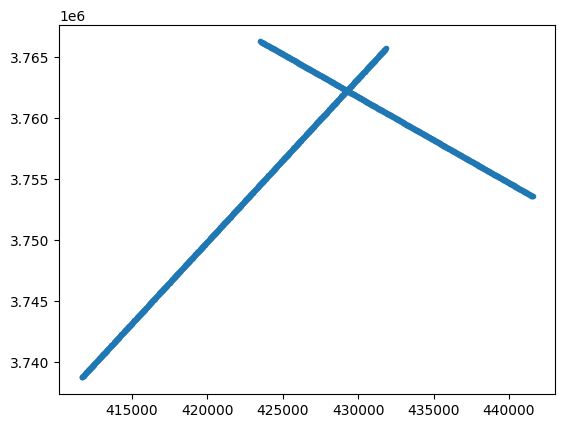

In [126]:

plt.plot(df_data_binned['x'], df_data_binned['y'], '.')

In [127]:
df_data_binned.keys()

Index(['Line', 'distance', 'x', 'y', 'DEM', 'radar', 'radarb', 'PLM', 'SFz[7]',
       'SFz[8]', 'SFz[9]', 'SFz[10]', 'SFz[11]', 'SFz[12]', 'SFz[13]',
       'SFz[14]', 'SFz[15]', 'SFz[16]', 'SFz[17]', 'SFz[18]', 'SFz[19]',
       'SFz[20]', 'SFz[21]', 'SFz[22]', 'SFz[23]', 'SFz[24]', 'SFz[25]',
       'SFz[26]', 'SFz[27]', 'SFz[28]', 'SFz[29]', 'SFz[30]', 'SFz[31]',
       'SFz[32]', 'SFz[33]', 'SFz[34]', 'SFz[35]', 'SFz[36]', 'SFz[37]',
       'SFz[38]', 'SFz[39]', 'SFz[40]', 'SFz[41]', 'SFz[42]', 'SFz[43]',
       'SFz[44]', 'SFz[45]', 'SFz[46]'],
      dtype='object')

In [128]:
# import geopandas as gpd
# from shapely.geometry import LineString
# # --- INPUTS ---
# number = 'vtem_max'
# out_shp  = f"{number}_lines.geojson"
# crs_epsg = 32613                 # <-- change (e.g., 4326 for lon/lat)

# # --- READ ---
# df = df_data_binned.copy()

# # Required columns
# xcol, ycol = "x", "y"

# # Optional columns:
# # - line_id: to create multiple line features
# # - seq: to order points along each line
# line_id_col = "Line" if "Line" in df.columns else None
# seq_col     = "seq" if "seq" in df.columns else None

# # --- BUILD LINES ---
# lines = []
# attrs = []

# if line_id_col:
#     grouped = df.groupby(line_id_col)
#     for lid, g in grouped:
#         coords = list(zip(g[xcol].to_numpy(), g[ycol].to_numpy()))
#         if len(coords) < 2:
#             continue
#         lines.append(LineString(coords))
#         attrs.append({line_id_col: lid})

# # --- WRITE SHAPEFILE ---
# gdf = gpd.GeoDataFrame(attrs, geometry=lines, crs=crs_epsg)
# gdf_kml = gdf.to_crs(4326)
# gdf_kml.to_file(out_shp)  # writes .shp/.shx/.dbf/.prj


# print(f"Wrote {len(gdf)} line(s) to {out_shp}")